# 15 — Astra tools: network accessibility and uncertainty

[Launch in JupyterLite](https://jltobias.github.io/JupyterLite-GeoLibre-GeoAI/lite/lab/index.html?path=15_astra_network_accessibility.ipynb)

Compute shortest travel times across a synthetic town, close a bridge, and inspect the resulting network, map and sensitivity curves. Give Astra a bounded analysis tool that summarizes computed routes. **Time:** about 30 minutes. **Prerequisites:** Python dictionaries; no graph library required.

**Runtime:** browser Python for the analysis; hosted GeoLibre for maps; optional CPython runner for Astra. The default run makes no model calls. The first run needs network access for packages, GeoLibre and interactive Plotly scripts. Static plots and local analysis do not depend on data APIs.

**Learning cycle:** predict → run → compare views → explain → test a different assumption.

## See the connections

![Accessibility: networks and counterfactuals: Network: Edges carry travel time, not straight-line distance; Scenario: Closing a bridge changes shortest routes; Astra tools: A bounded tool summarizes computed evidence; Check: Reachable nodes are not population coverage](assets/15_mindmap.svg)

In [1]:
import sys
if sys.platform == "emscripten":
    from pyodide import loadPackage
    await loadPackage(["numpy", "pandas", "matplotlib", "scipy", "pillow"])
    import micropip
    await micropip.install(["geolibre==3.0.0", "plotly==6.5.0"])
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from geolibre_lite import LiteMap as Map
from cognition import style_plots, COLORS, save_json
from astra_lab import make_request, response_text
style_plots()

## 1. Model the network, including the barrier

The 6 × 6 grid is invented. Each street segment takes two minutes; a river splits the grid between columns 2 and 3. Only two bridges cross it. The destination is node 0 (southwest). Closing one bridge is a counterfactual, not a real emergency scenario.

Predict which side of the river will gain the most travel time. Straight-line distance will not capture the detour.

In [2]:
import heapq
from cognition import local_lonlat
n=6
positions={r*n+c:(c*300,r*300) for r in range(n) for c in range(n)}
edges=[]
for r in range(n):
    for c in range(n):
        node=r*n+c
        if r<n-1: edges.append((node,node+n,2.0))
        if c<n-1 and (c!=2 or r in (1,4)): edges.append((node,node+1,2.0))
closed_bridge=(8,9)
def shortest_times(closed=False):
    graph={node:[] for node in positions}
    for a,b,cost in edges:
        if closed and (a,b)==closed_bridge: continue
        graph[a].append((b,cost)); graph[b].append((a,cost))
    best={node:float('inf') for node in positions}; best[0]=0
    queue=[(0,0)]
    while queue:
        time,node=heapq.heappop(queue)
        if time!=best[node]: continue
        for neighbor,cost in graph[node]:
            candidate=time+cost
            if candidate<best[neighbor]:
                best[neighbor]=candidate; heapq.heappush(queue,(candidate,neighbor))
    return best
baseline=shortest_times()
closure=shortest_times(closed=True)
routes=pd.DataFrame([{"node":node,"baseline":baseline[node],"bridge_closed":closure[node]} for node in positions])
routes['delay']=routes.bridge_closed-routes.baseline
display(routes.sort_values('delay',ascending=False).head())
assert baseline[0] == closure[0] == 0
assert all(closure[k] >= baseline[k] for k in positions)
assert baseline[9] == 8 and closure[9] == 20  # independent hand-traced paths

,node,baseline,bridge_closed,delay
3,3,10.0,22.0,12.0
10,10,10.0,22.0,12.0
5,5,14.0,26.0,12.0
4,4,12.0,24.0,12.0
11,11,12.0,24.0,12.0


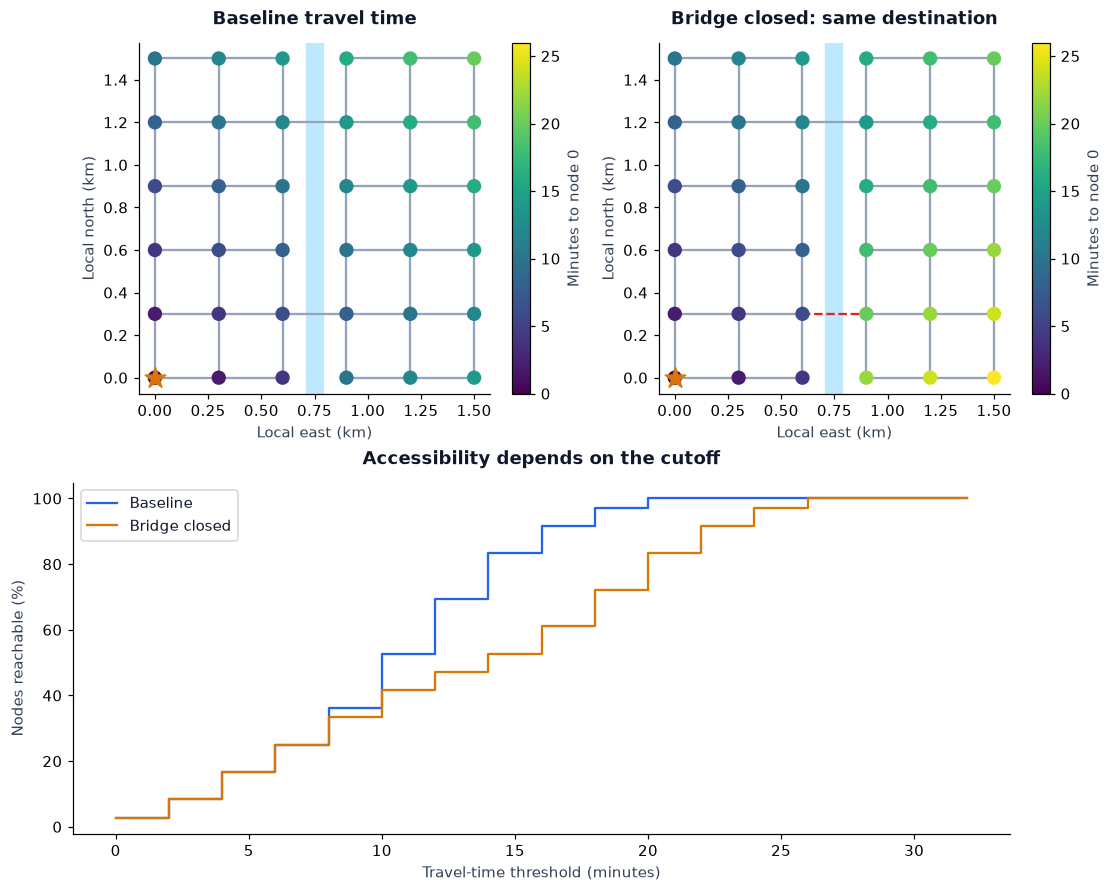

In [3]:
fig,panels=plt.subplot_mosaic([["baseline","closed"],["curve","curve"]],figsize=(10,8),layout="constrained")
axes=[panels[k] for k in ["baseline","closed","curve"]]
for ax,column,title in zip(axes[:2],['baseline','bridge_closed'],['Baseline travel time','Bridge closed: same destination']):
    ax.axvline(.75,color="#7dd3fc",lw=12,alpha=.5,zorder=0)
    for a,b,cost in edges:
        pa,pb=positions[a],positions[b]
        is_closed=column=='bridge_closed' and (a,b)==closed_bridge
        ax.plot([pa[0]/1000,pb[0]/1000],[pa[1]/1000,pb[1]/1000],
                color="#dc2626" if is_closed else "#94a3b8",ls="--" if is_closed else "-",zorder=1)
    pts=ax.scatter([p[0]/1000 for p in positions.values()],[p[1]/1000 for p in positions.values()],
                   c=routes[column],vmin=0,vmax=routes[['baseline','bridge_closed']].to_numpy().max(),cmap="viridis",s=70,zorder=2)
    ax.scatter(0,0,marker="*",s=200,c="#d97706",zorder=3)
    ax.set(xlabel="Local east (km)",ylabel="Local north (km)",title=title,aspect="equal")
    fig.colorbar(pts,ax=ax,label="Minutes to node 0")
thresholds=np.arange(0,33,2)
for column,label in [('baseline','Baseline'),('bridge_closed','Bridge closed')]:
    axes[2].step(thresholds,[100*routes[column].le(t).mean() for t in thresholds],where="post",label=label)
axes[2].set(xlabel="Travel-time threshold (minutes)",ylabel="Nodes reachable (%)",title="Accessibility depends on the cutoff")
axes[2].legend()
plt.show()

## 2. Compare geometry with the graph

GeoJSON carries the same nodes and edges. Point size encodes the extra minutes caused by closure, with a fixed minimum radius to keep zero-delay nodes visible. This counts nodes, not people, and the graph has no congestion or capacity constraints.

In [4]:
network_fc={"type":"FeatureCollection","features":[]}
for a,b,cost in edges:
    network_fc['features'].append({"type":"Feature","properties":{"minutes":cost,"closed":(a,b)==closed_bridge},
        "geometry":{"type":"LineString","coordinates":[local_lonlat(*positions[a]),local_lonlat(*positions[b])]}})
network_map=Map(center=(-122.291,37.907),zoom=13,height="520px")
network_map.add_geojson(network_fc,name="Synthetic streets",strokeColor="#64748b",strokeWidth=2)
for row in routes.itertuples():
    lon,lat=local_lonlat(*positions[row.node])
    network_map.add_marker(lon,lat,name=f"Node {row.node}: +{row.delay:.0f} min",
        properties={"node":row.node,"baseline_min":row.baseline,"closed_min":row.bridge_closed,"delay_min":row.delay},
        circleRadius=4+row.delay/2,fillColor="#d97706" if row.delay>0 else "#2563eb")
display(network_map)

## 3. Quantify sensitivity instead of inventing confidence

The band below varies all edge travel times by ±20%. It is a **scenario envelope**, not a statistical confidence interval. The closure still changes topology; the speed factor changes weights. Use both to explain why a single coverage percentage is incomplete.

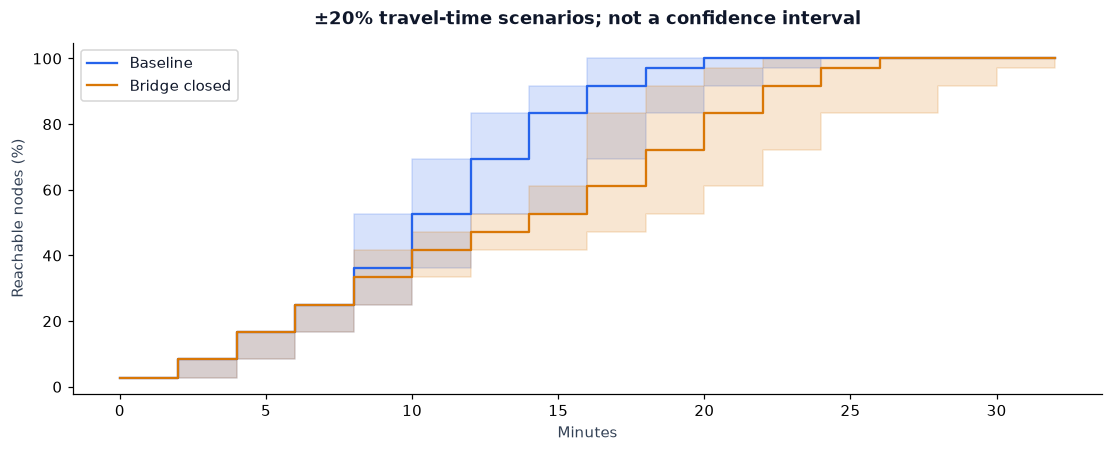

In [5]:
fig,ax=plt.subplots(figsize=(10,4),layout="constrained")
for column,label,color in [('baseline','Baseline',COLORS[0]),('bridge_closed','Bridge closed',COLORS[1])]:
    fast=np.array([100*(routes[column]*.8).le(t).mean() for t in thresholds])
    slow=np.array([100*(routes[column]*1.2).le(t).mean() for t in thresholds])
    ax.fill_between(thresholds,slow,fast,step="post",alpha=.18,color=color)
    ax.step(thresholds,[100*routes[column].le(t).mean() for t in thresholds],where="post",label=label,color=color)
ax.set(xlabel="Minutes",ylabel="Reachable nodes (%)",title="±20% travel-time scenarios; not a confidence interval")
ax.legend()
plt.show()

## 4. Give Astra a real bounded tool

`summarize_accessibility` can only select one of the two scenarios and a threshold from 0 to 120 minutes. Python computes the result from exported routes. The replay below uses **hand-authored arguments**, not a model call. Try an unknown tool name and check that dispatch rejects it.

For live use, the CPython runner sends the tool definition to Astra, validates its arguments, returns the calculated result using `function_call_output`, and preserves response reasoning items between rounds. It never grants shell access or executes generated code.

In [6]:
from astra_lab import ACCESS_TOOL, dispatch_tool
evidence={"evidence_id":"routes","source":"synthetic 6x6 network","units":"minutes",
          "destination_node":0,"closed_bridge":list(closed_bridge),"routes":routes.to_dict('records')}
replay=dispatch_tool("summarize_accessibility",{"scenario":"bridge_closed","threshold_minutes":12},evidence)
display(replay)
request=make_request("Use summarize_accessibility for BOTH baseline and bridge_closed at 12 minutes. Compare the returned fractions. Cite routes; explain why node coverage is not population coverage and why the speed band is not a confidence interval.",
                     {k:v for k,v in evidence.items() if k!='routes'})
request['tools']=[ACCESS_TOOL]
save_json("exports/accessibility_request.json",request)
save_json("exports/accessibility_evidence.json",evidence)
save_json("exports/accessibility.geolibre.json",network_map.to_project())

{'evidence_id': 'routes',
 'scenario': 'bridge_closed',
 'threshold_minutes': 12,
 'reachable_nodes': 17,
 'total_nodes': 36,
 'fraction': 0.4722222222222222,
 'interpretation': 'Fraction of synthetic nodes, not residents or real service coverage'}

'exports\\accessibility.geolibre.json'

## Optional: run this request with GPT-6 Astra

All calculations above run locally. The exported request has **not been sent** and any example plan is **hand-authored**, not a recorded model response. To obtain a live response:

1. Download the generated request from JupyterLite's file browser (right-click → Download).
2. In a full CPython terminal in this repository, set `OPENAI_API_KEY` in that terminal's environment. Never put the key in a notebook, output, or the static site.
3. Preview with `python scripts/run_astra.py PATH_TO_REQUEST.json`. Send deliberately with `--send --output astra_response.json`. This uses your API account and can incur charges.
4. Upload `astra_response.json` to the notebook folder, set the import path in the next cell, and rerun it. Inspect its evidence claims before using them.

For notebook 15, also download `accessibility_evidence.json` and pass `--evidence PATH_TO_EVIDENCE.json`. The runner only dispatches the one allowlisted local tool, with a bounded number of rounds.

The static JupyterLite site does not host this runner or proxy requests. Model access depends on your API project. Image reading is an aid to interpretation; geometry, distances and metrics come from code and explicit metadata.

In [7]:
RESPONSE_PATH=None
if RESPONSE_PATH:
    display(json.loads(response_text(json.loads(Path(RESPONSE_PATH).read_text()))))
else:
    print("Replay only. No Astra tool calls have been made.")

Replay only. No Astra tool calls have been made.


## 5. Evaluate a spatial explanation

Score a live answer against these checks: does it cite `routes`, use both computed fractions, identify the cutoff, distinguish nodes from people, and label the speed band correctly? A fluent answer can fail any of these checks.

**Transfer:** replace the fixture with a licensed road graph and validated edge costs in full Python. Join population only after choosing a defensible allocation method, account for disconnected nodes, and document the network date. Return GeoJSON predictions to GeoLibre and use Astra to review evidence and propose testable follow-up questions.

**Experiment:** close both bridges. Some nodes become unreachable; encode those times as JSON `null`, never `Infinity`, before using the provided tool. Explain why a straight-line buffer would miss the disconnection.

## Data & software citations

- Teaching fixtures: deterministic synthetic arrays and networks authored in this repository. Values, scenes, facilities and outcomes are invented; coordinates only anchor the display. No actual people, environmental measurements, or service areas are represented.
- [GeoLibre](https://geolibre.app/) and [GeoLibre map controls](https://geolibre.app/user-guide/map-controls/); `geolibre==3.0.0` project builders through `geolibre_lite.LiteMap`.
- [GeoAI](https://opengeoai.org/): full Python/GPU continuation for imagery models. These browser labs implement workflow patterns; they do not install or run `geoai-py`.
- [GPT-6 Astra model](https://developers.openai.com/api/docs/models/gpt-6-astra), [Structured Outputs](https://developers.openai.com/api/docs/guides/structured-outputs), [image inputs](https://developers.openai.com/api/docs/guides/images-vision), and [function calling](https://developers.openai.com/api/docs/guides/function-calling). API examples checked 2026-10-02.
- [Pyodide packages](https://pyodide.org/en/stable/usage/packages-in-pyodide.html), [Matplotlib](https://matplotlib.org/stable/), [Plotly Python](https://plotly.com/python/).
- GeoLibre basemap tiles retain their provider attribution, including [OpenStreetMap contributors](https://www.openstreetmap.org/copyright) where applicable.

See `DATA_SOURCES.md` for the source register and runtime boundaries.